In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.linear_model import Perceptron, LogisticRegression, SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PowerTransformer

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_LIMPOS
from src.graficos import plot_coeficientes, plot_comparar_metricas_modelos
from src.models import RANDOM_STATE
from src.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html

In [30]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,...,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,...,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,...,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,...,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,...,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [31]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [32]:
le = LabelEncoder()

y = le.fit_transform(y)

y[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

Em machine learning, trabalhamos frequentemente com conjuntos de dados que possuem um grande número de variáveis, também chamadas de *features* ou atributos. Embora possa parecer vantajoso utilizar o máximo de informações possível ao treinar um modelo, na prática, nem todas as variáveis contribuem de forma significativa para a performance do modelo. Algumas podem até introduzir ruído ou redundância, prejudicando a capacidade de generalização.

A seleção de variáveis, ou *feature selection*, é o processo de identificar e selecionar um subconjunto relevante de variáveis para utilizar na construção de um modelo preditivo. O objetivo é melhorar a performance do modelo, reduzir o tempo de treinamento e facilitar a interpretação dos resultados.

1. **Redução de Dimensionalidade**: Trabalhar com menos variáveis diminui a complexidade do modelo, o que pode levar a melhores resultados, especialmente em conjuntos de dados com muitas dimensões (o chamado "problema da maldição da dimensionalidade").

2. **Melhora na Performance**: Removendo variáveis irrelevantes ou redundantes, o modelo pode focar nas informações mais importantes, o que geralmente melhora a precisão e a capacidade de generalização.

3. **Redução de *Overfitting***: Modelos treinados com muitas variáveis irrelevantes têm maior chance de se ajustar ao ruído dos dados de treinamento, o que prejudica a performance em dados não vistos.

4. **Interpretação Simplificada**: Com menos variáveis, é mais fácil entender e interpretar como o modelo toma decisões, o que é crucial em muitas aplicações práticas.

Existem diversas técnicas para realizar a seleção de variáveis, que podem ser categorizadas em três grupos principais:

1. **Métodos *Filter* (Filtro)**: Baseiam-se em características estatísticas das variáveis, sem considerar nenhum algoritmo de aprendizado específico. Exemplos incluem o uso de correlação, teste de qui-quadrado e informação mútua.

2. **Métodos *Wrapper* (Envoltório)**: Utilizam um algoritmo de aprendizado para avaliar a performance de diferentes subconjuntos de variáveis. Apesar de serem mais precisos, são computacionalmente mais custosos. Exemplos incluem a busca exaustiva, seleção sequencial e eliminação recursiva de variáveis (*Recursive Feature Elimination*).

3. **Métodos *Embedded* (Embutidos)**: Realizam a seleção de variáveis durante o processo de treinamento do modelo. Alguns algoritmos têm essa capacidade intrínseca, como árvores de decisão e modelos com regularização (como Lasso e Ridge Regression).


https://scikit-learn.org/stable/modules/feature_selection.html

**O que é o SelectKBest?**

O `SelectKBest` é uma ferramenta de seleção de variáveis fornecida pelo Scikit-Learn, que faz parte dos métodos de seleção *filter* (filtro). Ele seleciona as **K melhores variáveis** baseando-se em testes estatísticos univariados entre cada variável independente e a variável dependente (a que você quer prever).

1. **Análise Univariada**: O `SelectKBest` considera cada variável independentemente, avaliando sua relação com a variável alvo sem levar em conta as outras variáveis.

2. **Função de Pontuação**: Ele utiliza uma função estatística de pontuação (*score function*) para avaliar a relevância de cada variável. No caso de classificação, as funções de pontuação comuns incluem:
   - **Chi-quadrado (`chi2`)**: Avalia a independência entre variáveis categóricas.
   - **ANOVA F-test (`f_classif`)**: Mede a correlação linear entre cada variável e a classe.
   - **Informação Mútua (`mutual_info_classif`)**: Captura qualquer tipo de dependência entre variáveis, incluindo relações não lineares.

3. **Ordenação das Variáveis**: Após calcular as pontuações, as variáveis são ordenadas da mais para a menos relevante com base nos resultados da função de pontuação.

4. **Seleção das K Melhores**: Finalmente, são selecionadas as **K variáveis** com as maiores pontuações para serem utilizadas no modelo.

**Por que Usar o SelectKBest em Classificação?**

- **Simplicidade e Eficiência**: Sendo um método univariado, o `SelectKBest` é rápido e simples de implementar, tornando-se adequado para conjuntos de dados grandes.

- **Redução de Ruído**: Ao remover variáveis irrelevantes, o modelo fica menos propenso a ajustar-se ao ruído dos dados, melhorando sua capacidade de generalização.

- **Melhora na Interpretação**: Com menos variáveis, torna-se mais fácil interpretar o modelo e entender quais features influenciam mais a predição.

**Considerações Importantes**

- **Univariado vs. Multivariado**: Como o `SelectKBest` avalia cada variável isoladamente, ele não captura interações entre variáveis. Portanto, pode não identificar conjuntos de variáveis que são relevantes apenas quando consideradas em conjunto.

- **Definição de K**: Determinar o número ideal de variáveis (*K*) pode requerer experimentação ou validação cruzada para encontrar o equilíbrio entre desempenho e complexidade.


https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html

O teste qui-quadrado (`chi2`) é uma medida estatística utilizada para avaliar a independência entre duas variáveis categóricas. No contexto da seleção de features, ele mede o grau de associação entre cada feature e a variável alvo.

- **Construção de Tabelas de Contingência:** Para cada feature, é criada uma tabela que relaciona as frequências observadas dos valores da feature com as classes da variável alvo.
- **Cálculo do Estatístico Chi-Quadrado:** O valor do qui-quadrado é calculado comparando as frequências observadas com as frequências esperadas sob a hipótese de independência.
- **Interpretação:** Um valor alto do chi-quadrado indica que há uma associação significativa entre a feature e a classe, ou seja, a feature é relevante para a predição.

**Considerações Importantes:**

- **Dados Não Negativos:** O teste chi-quadrado requer que os dados sejam não negativos (geralmente contagens ou frequências).
- **Features Categóricas ou Discretas:** É mais adequado para features categóricas ou que foram discretizadas.
- **Não Captura Relações Lineares ou Não Lineares:** Apenas mede a independência entre variáveis categóricas.


O `f_classif` utiliza o teste F da análise de variância (ANOVA) para avaliar se existem diferenças estatisticamente significativas entre as médias dos grupos definidos pelas classes da variável alvo em relação a cada feature contínua.

- **Variância Entre e Dentro dos Grupos:** O teste F compara a variabilidade das médias entre os diferentes grupos (classes) com a variabilidade dentro dos grupos.
- **Cálculo do Estatístico F:** O valor F é calculado como a razão entre a variância explicada pela feature (entre os grupos) e a variância residual (dentro dos grupos).
- **Interpretação:** Um valor F alto sugere que a feature tem um efeito significativo na distinção entre as classes, indicando relevância para a predição.

**Considerações Importantes:**

- **Assunção de Normalidade:** Presume que os dados seguem uma distribuição normal em cada grupo.
- **Homogeneidade de Variâncias:** Assume que as variâncias são iguais entre os grupos (homocedasticidade).
- **Adequado para Features Contínuas:** Melhor utilizado com features numéricas contínuas.

A informação mútua (`mutual_info_classif`) é uma medida da dependência mútua entre duas variáveis. Baseia-se na teoria da informação e quantifica a quantidade de informação que uma variável fornece sobre outra, capturando tanto relações lineares quanto não lineares.

- **Cálculo da Entropia:** Mede a incerteza associada a uma variável.
- **Informação Mútua:** Calcula a redução na incerteza da variável alvo proporcionada pelo conhecimento da feature.
- **Estimativa Não Paramétrica:** Usa métodos como estimadores de k-vizinhos mais próximos para estimar a informação mútua sem assumir uma forma específica de distribuição dos dados.

**Interpretação:**

- **Valor Sempre Não Negativo:** Um valor zero indica independência completa; valores maiores que zero indicam dependência.
- **Captura Relações Complexas:** Capaz de detectar qualquer tipo de relação entre as variáveis, seja linear ou não linear.

**Considerações Importantes:**

- **Flexibilidade:** Pode ser aplicado tanto a features contínuas quanto categóricas.
- **Não Requer Assunções sobre Distribuição dos Dados:** Não depende de pressupostos como normalidade ou homocedasticidade.

### **Resumo Comparativo:**

- **`chi2`:**
  - **Tipo de Dados:** Features categóricas ou discretas não negativas.
  - **Captura:** Associação entre variáveis categóricas.
  - **Limitações:** Não adequado para dados contínuos ou negativos.

- **`f_classif`:**
  - **Tipo de Dados:** Features contínuas.
  - **Captura:** Relações lineares entre a feature e a classe.
  - **Limitações:** Requer assunções estatísticas (normalidade e homocedasticidade).

- **`mutual_info_classif`:**
  - **Tipo de Dados:** Features contínuas ou categóricas.
  - **Captura:** Relações lineares e não lineares.
  - **Limitações:** Valores de informação mútua não são diretamente comparáveis em escala.


### **Como Escolher a Função de Pontuação Adequada:**

- **Natureza dos Dados:**
  - **Categóricos/Discretos:** Use `chi2` ou `mutual_info_classif`.
  - **Contínuos:** Use `f_classif` ou `mutual_info_classif`.

- **Relação Esperada:**
  - **Linear:** `f_classif` é apropriado.
  - **Não Linear ou Desconhecida:** `mutual_info_classif` é preferível.

- **Assunções Estatísticas:**
  - **Se as Assunções São Atendidas:** `f_classif` pode ser mais poderoso.
  - **Se as Assunções Não São Atendidas:** `mutual_info_classif` não depende de assunções.

### **Considerações Específicas:**

- **`chi2`:**
  - **Pré-Processamento:** Pode ser necessário discretizar features contínuas ou converter dados categóricos em codificação numérica (por exemplo, one-hot encoding).
  - **Aplicações Comuns:** Seleção de palavras em modelos de classificação de texto (onde os dados são frequências de palavras).

- **`f_classif`:**
  - **Escala dos Dados:** É sensível à escala; padronizar os dados pode ser benéfico.
  - **Aplicações Comuns:** Problemas onde as features são medidas contínuas, como atributos físicos ou financeiros.

- **`mutual_info_classif`:**
  - **Computacionalmente Mais Custoso:** Pode ser mais lento devido à estimativa não paramétrica.
  - **Aplicações Comuns:** Cenários onde se espera relações complexas entre features e a variável alvo.



In [33]:
#Select K Best Quiadrado
seletor_chi2 = SelectKBest(score_func=chi2, k=15)
X_chi2 = seletor_chi2.fit_transform(X, y)   
X_chi2.shape

(569, 15)

In [34]:
X_chi2[:5]

array([[1.001e+03, 1.534e+02, 2.019e+03, 6.656e-01, 2.654e-01, 3.001e-01,
        7.119e-01, 1.228e+02, 8.589e+00, 1.846e+02, 1.799e+01, 1.095e+00,
        2.538e+01, 1.038e+01, 1.733e+01],
       [1.326e+03, 7.408e+01, 1.956e+03, 1.866e-01, 1.860e-01, 8.690e-02,
        2.416e-01, 1.329e+02, 3.398e+00, 1.588e+02, 2.057e+01, 5.435e-01,
        2.499e+01, 1.777e+01, 2.341e+01],
       [1.203e+03, 9.403e+01, 1.709e+03, 4.245e-01, 2.430e-01, 1.974e-01,
        4.504e-01, 1.300e+02, 4.585e+00, 1.525e+02, 1.969e+01, 7.456e-01,
        2.357e+01, 2.125e+01, 2.553e+01],
       [3.861e+02, 2.723e+01, 5.677e+02, 8.663e-01, 2.575e-01, 2.414e-01,
        6.869e-01, 7.758e+01, 3.445e+00, 9.887e+01, 1.142e+01, 4.956e-01,
        1.491e+01, 2.038e+01, 2.650e+01],
       [1.297e+03, 9.444e+01, 1.575e+03, 2.050e-01, 1.625e-01, 1.980e-01,
        4.000e-01, 1.351e+02, 5.438e+00, 1.522e+02, 2.029e+01, 7.572e-01,
        2.254e+01, 1.434e+01, 1.667e+01]])

In [35]:
seletor_chi2.scores_

array([5.39916559e+04, 8.75850471e+03, 1.12598432e+05, 5.40307549e+00,
       6.13785332e-01, 1.93149220e+01, 1.05440354e+01, 3.05231563e-01,
       1.34854195e+01, 1.97123536e+01, 1.04471761e+00, 3.95169151e+01,
       7.43065536e-05, 6.37136566e-03, 2.31522407e-01, 2.01110286e+03,
       2.50571896e+02, 3.66503542e+03, 2.66104917e+02, 3.46752472e+01,
       4.91689157e+02, 1.49899264e-01, 3.26620664e-03, 3.97365694e-01,
       2.57379775e-01, 8.03633831e-05, 1.29886140e+00, 9.38975081e+01,
       9.79353970e-03, 1.74449400e+02])

In [36]:
seletor_chi2.pvalues_

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 2.01012999e-002,
       4.33366115e-001, 1.10836762e-005, 1.16563638e-003, 5.80621137e-001,
       2.40424384e-004, 9.00175712e-006, 3.06726812e-001, 3.25230064e-010,
       9.93122221e-001, 9.36379753e-001, 6.30397277e-001, 0.00000000e+000,
       1.94877489e-056, 0.00000000e+000, 8.01397628e-060, 3.89553429e-009,
       6.11324751e-109, 6.98631644e-001, 9.54425121e-001, 5.28452867e-001,
       6.11926026e-001, 9.92847410e-001, 2.54421307e-001, 3.32292194e-022,
       9.21168192e-001, 7.89668299e-040])

In [37]:
seletor_chi2.get_support()

array([ True,  True,  True, False, False,  True, False, False,  True,
        True, False,  True, False, False, False,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
        True, False,  True])

In [38]:
seletor_chi2.get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_worst',
       'concave points_worst', 'concavity_mean', 'concavity_worst',
       'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'radius_mean',
       'radius_se', 'radius_worst', 'texture_mean', 'texture_worst'],
      dtype=object)

In [39]:
#Select K Best F-ANOVA
seletor_f = SelectKBest(score_func=f_classif, k=15)
X_f = seletor_f.fit_transform(X, y)   
X_f.shape

(569, 15)

In [40]:
X_f[:5]

array([[1.001e+03, 1.534e+02, 2.019e+03, 2.776e-01, 6.656e-01, 1.471e-01,
        2.654e-01, 3.001e-01, 7.119e-01, 1.228e+02, 8.589e+00, 1.846e+02,
        1.799e+01, 1.095e+00, 2.538e+01],
       [1.326e+03, 7.408e+01, 1.956e+03, 7.864e-02, 1.866e-01, 7.017e-02,
        1.860e-01, 8.690e-02, 2.416e-01, 1.329e+02, 3.398e+00, 1.588e+02,
        2.057e+01, 5.435e-01, 2.499e+01],
       [1.203e+03, 9.403e+01, 1.709e+03, 1.599e-01, 4.245e-01, 1.279e-01,
        2.430e-01, 1.974e-01, 4.504e-01, 1.300e+02, 4.585e+00, 1.525e+02,
        1.969e+01, 7.456e-01, 2.357e+01],
       [3.861e+02, 2.723e+01, 5.677e+02, 2.839e-01, 8.663e-01, 1.052e-01,
        2.575e-01, 2.414e-01, 6.869e-01, 7.758e+01, 3.445e+00, 9.887e+01,
        1.142e+01, 4.956e-01, 1.491e+01],
       [1.297e+03, 9.444e+01, 1.575e+03, 1.328e-01, 2.050e-01, 1.043e-01,
        1.625e-01, 1.980e-01, 4.000e-01, 1.351e+02, 5.438e+00, 1.522e+02,
        2.029e+01, 7.572e-01, 2.254e+01]])

In [41]:
seletor_f.scores_

array([5.73060747e+02, 2.43651586e+02, 6.61600206e+02, 3.13233079e+02,
       5.32473391e+01, 3.04341063e+02, 8.61676020e+02, 1.13262760e+02,
       9.64385393e+02, 5.33793126e+02, 3.90144816e+01, 4.36691939e+02,
       9.34592949e-02, 3.46827476e+00, 6.64439606e+01, 6.97235272e+02,
       2.53897392e+02, 8.97944219e+02, 6.46981021e+02, 2.68840327e+02,
       8.60781707e+02, 8.36511234e+01, 2.55796780e+00, 1.22472880e+02,
       6.95274435e+01, 2.41174067e-02, 1.18860232e+02, 1.18096059e+02,
       3.90947023e-02, 1.49596905e+02])

In [42]:
seletor_f.pvalues_

array([4.73456431e-088, 5.89552139e-046, 2.82884770e-097, 3.93826311e-056,
       9.97599465e-013, 7.06981635e-055, 7.10115016e-116, 3.07230877e-024,
       1.96909971e-124, 9.96655576e-084, 8.26017617e-010, 2.46466396e-072,
       7.59936804e-001, 6.30735508e-002, 2.31643245e-015, 8.43625104e-101,
       1.65190518e-047, 5.77139714e-119, 8.46594057e-096, 9.73894866e-050,
       8.48229192e-116, 1.05185036e-018, 1.10296609e-001, 6.57514363e-026,
       5.73338403e-016, 8.76641818e-001, 2.95112058e-025, 4.05863605e-025,
       8.43332029e-001, 1.07805749e-030])

In [43]:
seletor_f.get_support()

array([ True,  True,  True,  True, False,  True,  True, False,  True,
        True, False,  True, False, False, False,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False])

In [44]:
seletor_f.get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_mean',
       'compactness_worst', 'concave points_mean', 'concave points_worst',
       'concavity_mean', 'concavity_worst', 'perimeter_mean',
       'perimeter_se', 'perimeter_worst', 'radius_mean', 'radius_se',
       'radius_worst'], dtype=object)

In [45]:
#Select K Best Mutual Information
seletor_mi = SelectKBest(score_func=mutual_info_classif, k=15)
X_mi = seletor_mi.fit_transform(X, y)   
X_mi.shape

(569, 15)

In [46]:
X_f[:5]

array([[1.001e+03, 1.534e+02, 2.019e+03, 2.776e-01, 6.656e-01, 1.471e-01,
        2.654e-01, 3.001e-01, 7.119e-01, 1.228e+02, 8.589e+00, 1.846e+02,
        1.799e+01, 1.095e+00, 2.538e+01],
       [1.326e+03, 7.408e+01, 1.956e+03, 7.864e-02, 1.866e-01, 7.017e-02,
        1.860e-01, 8.690e-02, 2.416e-01, 1.329e+02, 3.398e+00, 1.588e+02,
        2.057e+01, 5.435e-01, 2.499e+01],
       [1.203e+03, 9.403e+01, 1.709e+03, 1.599e-01, 4.245e-01, 1.279e-01,
        2.430e-01, 1.974e-01, 4.504e-01, 1.300e+02, 4.585e+00, 1.525e+02,
        1.969e+01, 7.456e-01, 2.357e+01],
       [3.861e+02, 2.723e+01, 5.677e+02, 2.839e-01, 8.663e-01, 1.052e-01,
        2.575e-01, 2.414e-01, 6.869e-01, 7.758e+01, 3.445e+00, 9.887e+01,
        1.142e+01, 4.956e-01, 1.491e+01],
       [1.297e+03, 9.444e+01, 1.575e+03, 1.328e-01, 2.050e-01, 1.043e-01,
        1.625e-01, 1.980e-01, 4.000e-01, 1.351e+02, 5.438e+00, 1.522e+02,
        2.029e+01, 7.572e-01, 2.254e+01]])

In [47]:
seletor_mi.scores_

array([0.35944473, 0.34056444, 0.4644563 , 0.21304884, 0.0758874 ,
       0.2252268 , 0.43968865, 0.12591659, 0.43652592, 0.3723677 ,
       0.11942488, 0.31534308, 0.01020758, 0.0396224 , 0.06758843,
       0.40305497, 0.27564978, 0.47298839, 0.36824625, 0.24930495,
       0.45472333, 0.08108417, 0.01513245, 0.10476038, 0.06465055,
       0.01330097, 0.09738739, 0.09805919, 0.00242252, 0.12301038])

In [48]:
seletor_mi.pvalues_

In [49]:
seletor_mi.get_support()

array([ True,  True,  True,  True, False,  True,  True, False,  True,
        True, False,  True, False, False, False,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False])

In [50]:
seletor_f.get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_mean',
       'compactness_worst', 'concave points_mean', 'concave points_worst',
       'concavity_mean', 'concavity_worst', 'perimeter_mean',
       'perimeter_se', 'perimeter_worst', 'radius_mean', 'radius_se',
       'radius_worst'], dtype=object)

In [51]:
comparar_colunas = pd.DataFrame(
    {
        "Chi-Square": seletor_chi2.get_support(),
        "ANOVA F": seletor_f.get_support(),
        "Mutual Information": seletor_mi.get_support(),
    },index=X.columns
)
comparar_colunas

,Chi-Square,ANOVA F,Mutual Information
area_mean,True,True,True
area_se,True,True,True
area_worst,True,True,True
compactness_mean,False,True,True
compactness_se,False,False,False
compactness_worst,True,True,True
concave points_mean,False,True,True
concave points_se,False,False,False
concave points_worst,True,True,True
concavity_mean,True,True,True


In [52]:
#Pegar as linhas que foram selecionadas pelos tres métodos
colunas_selecionadas = comparar_colunas[
    (comparar_colunas["Chi-Square"] == True)
    & (comparar_colunas["ANOVA F"] == True)
    & (comparar_colunas["Mutual Information"] == True)
]

colunas_selecionadas

,Chi-Square,ANOVA F,Mutual Information
area_mean,True,True,True
area_se,True,True,True
area_worst,True,True,True
compactness_worst,True,True,True
concave points_worst,True,True,True
concavity_mean,True,True,True
concavity_worst,True,True,True
perimeter_mean,True,True,True
perimeter_se,True,True,True
perimeter_worst,True,True,True


Avaliando o cenário do nosso dataframe, a melhor função de selecão de variáveis seria o `mutual_info_classif`

In [53]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [54]:
preprocessamento = Pipeline(
    steps=[
        ("scaler", PowerTransformer()),
        ("seletor", SelectKBest(score_func=mutual_info_classif, k=15))
        ]
)

In [55]:
classificadores = {
    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },
    "Perceptron": {
        "preprocessor": preprocessamento,
        "classificador": Perceptron()
    },
    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression()
    },
    "SGDClassifier": {
        "preprocessor": preprocessamento,
        "classificador": SGDClassifier()
    },
}

In [56]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.004,0.023985,0.412281,0.363085,0.17284,0.184211,0.162791,0.463479,0.362439,0.027985
1,DummyClassifier,0.004005,0.022979,0.517544,0.493449,0.382022,0.369565,0.395349,0.477563,0.367611,0.026985
2,DummyClassifier,0.001999,0.021987,0.605263,0.583333,0.482759,0.466667,0.5,0.52877,0.38313,0.023986
3,DummyClassifier,0.002999,0.021985,0.578947,0.552579,0.44186,0.431818,0.452381,0.519841,0.378228,0.024984
4,DummyClassifier,0.002999,0.022983,0.495575,0.442991,0.25974,0.285714,0.238095,0.41214,0.345703,0.025982
5,Perceptron,0.666965,0.025987,0.938596,0.918605,0.911392,1.0,0.837209,0.987881,0.982831,0.692952
6,Perceptron,0.644131,0.029,0.894737,0.865051,0.842105,0.969697,0.744186,0.985915,0.977328,0.673131
7,Perceptron,0.588936,0.027984,0.921053,0.922619,0.896552,0.866667,0.928571,0.982143,0.978283,0.61692
8,Perceptron,0.59699,0.027135,0.95614,0.960317,0.942529,0.911111,0.97619,0.995701,0.993515,0.624125
9,Perceptron,0.586884,0.027967,0.964602,0.952381,0.95,1.0,0.904762,0.996982,0.995172,0.614851


In [57]:
df_resultados.groupby("model").mean().sort_values("test_recall")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.0032,0.022784,0.521922,0.487088,0.347844,0.347595,0.349723,0.480358,0.367422,0.025984
Perceptron,0.616781,0.027615,0.935026,0.923795,0.908516,0.949495,0.878184,0.989724,0.985426,0.644396
SGDClassifier,0.626682,0.027186,0.942012,0.932501,0.919262,0.945179,0.895792,0.988183,0.982479,0.653867
LogisticRegression,0.737993,0.03626,0.952585,0.947818,0.935613,0.944606,0.929125,0.992078,0.989293,0.774253


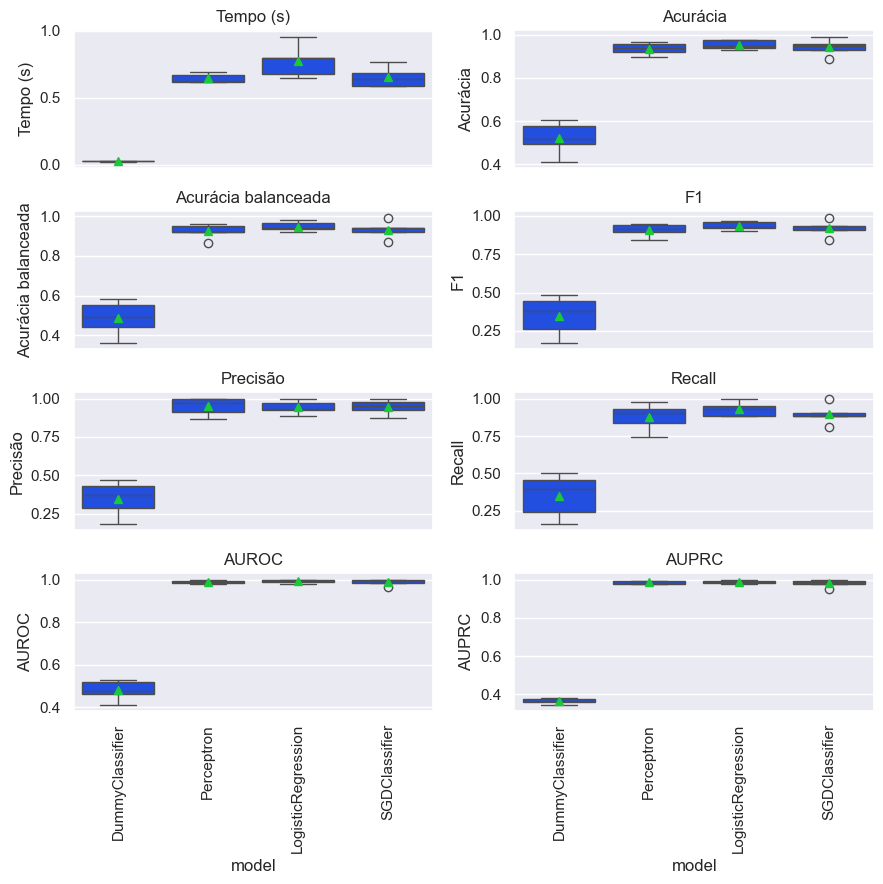

In [58]:
plot_comparar_metricas_modelos(df_resultados)

In [59]:
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__l1_ratio": [0.0, 0.1, 0.5, 1.0],
    "clf__class_weight": [None, "balanced"],
}

In [60]:
clf = LogisticRegression(solver="saga", random_state=RANDOM_STATE)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessamento, refit_metric="recall"
)

grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': [None, 'balanced'], 'clf__l1_ratio': [0.0, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [61]:
grid_search.fit(X, y)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\gabri\anaconda3\envs\breast_cancer\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': [None, 'balanced'], 'clf__l1_ratio': [0.0, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'balanced_accuracy', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [62]:
grid_search.best_params_

{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0.0}

In [63]:
grid_search.best_score_

np.float64(0.9527131782945737)

In [64]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('seletor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normal

In [65]:
grid_search.best_estimator_["preprocessor"].get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_mean',
       'compactness_worst', 'concave points_mean', 'concave points_worst',
       'concavity_mean', 'concavity_worst', 'perimeter_mean',
       'perimeter_se', 'perimeter_worst', 'radius_mean', 'radius_se',
       'radius_worst'], dtype=object)

In [66]:
grid_search.best_estimator_["clf"].coef_

array([[-0.32498428,  1.18476726,  1.42458284, -1.44492982,  0.28088442,
         1.32090234,  1.53174116,  0.04005868,  1.22411141, -0.41532768,
        -0.37079043,  0.92070109, -0.47753381,  0.54755456,  1.2232131 ]])

In [67]:
coefs = dataframe_coeficientes(
    grid_search.best_estimator_["clf"].coef_[0],
    grid_search.best_estimator_["preprocessor"].get_feature_names_out()
)

coefs

,coeficiente
compactness_mean,-1.444930
radius_mean,-0.477534
perimeter_mean,-0.415328
perimeter_se,-0.370790
area_mean,-0.324984
concavity_mean,0.040059
compactness_worst,0.280884
radius_se,0.547555
perimeter_worst,0.920701
area_se,1.184767


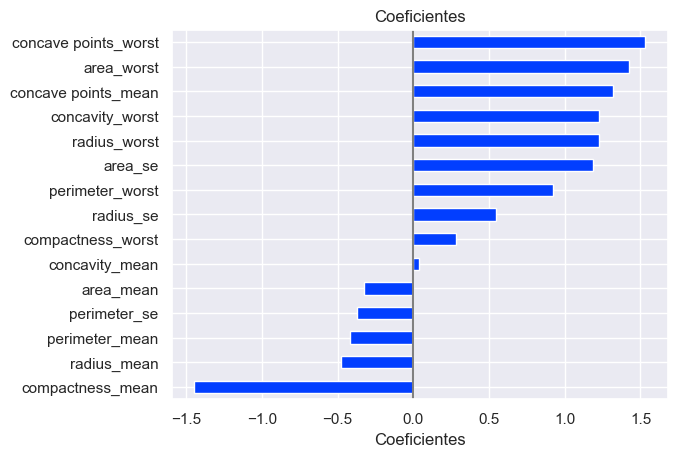

In [68]:
plot_coeficientes(coefs)

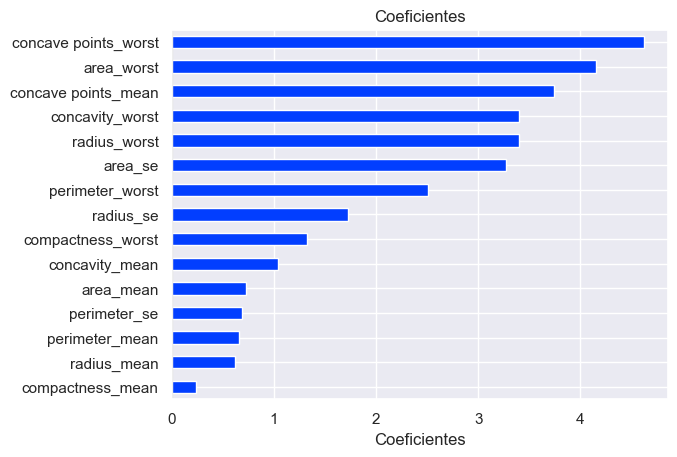

In [69]:
coefs_odds = coefs.copy()
coefs_odds["coeficiente"] = np.exp(coefs_odds["coeficiente"])

plot_coeficientes(coefs_odds)

In [70]:
coefs_odds

,coeficiente
compactness_mean,0.235763
radius_mean,0.620311
perimeter_mean,0.660124
perimeter_se,0.690189
area_mean,0.722539
concavity_mean,1.040872
compactness_worst,1.324301
radius_se,1.729020
perimeter_worst,2.511050
area_se,3.269926


In [71]:
X_scaled = grid_search.best_estimator_["preprocessor"].transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=grid_search.best_estimator_["preprocessor"].get_feature_names_out())

X_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_worst,concave points_mean,concave points_worst,concavity_mean,concavity_worst,perimeter_mean,perimeter_se,perimeter_worst,radius_mean,radius_se,radius_worst
0,1.126421,1.876109,1.652210,2.165938,1.942737,1.848558,1.935654,1.862988,1.730182,1.259822,1.973081,1.810506,1.134881,1.892785,1.619635
1,1.633946,1.276861,1.610022,-0.384102,-0.296580,0.820609,1.101594,0.291976,0.070746,1.528723,0.732407,1.430616,1.619346,0.958616,1.578689
2,1.461645,1.496107,1.425307,1.163977,1.209701,1.683104,1.722744,1.403673,1.005512,1.454664,1.213029,1.321941,1.464796,1.457817,1.419757
3,-0.836238,0.045515,-0.436860,2.197843,2.282276,1.423004,1.862378,1.642391,1.675087,-0.514886,0.756164,-0.039480,-0.759262,0.791676,-0.083692
4,1.595120,1.499885,1.309486,0.762392,-0.131829,1.410929,0.807077,1.407479,0.817474,1.583341,1.451685,1.316582,1.571260,1.479006,1.293727


In [72]:
df_scaled = pd.concat([X_scaled, pd.Series(y, name="diagnosis")], axis=1)

df_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_worst,concave points_mean,concave points_worst,concavity_mean,concavity_worst,perimeter_mean,perimeter_se,perimeter_worst,radius_mean,radius_se,radius_worst,diagnosis
0,1.126421,1.876109,1.652210,2.165938,1.942737,1.848558,1.935654,1.862988,1.730182,1.259822,1.973081,1.810506,1.134881,1.892785,1.619635,1
1,1.633946,1.276861,1.610022,-0.384102,-0.296580,0.820609,1.101594,0.291976,0.070746,1.528723,0.732407,1.430616,1.619346,0.958616,1.578689,1
2,1.461645,1.496107,1.425307,1.163977,1.209701,1.683104,1.722744,1.403673,1.005512,1.454664,1.213029,1.321941,1.464796,1.457817,1.419757,1
3,-0.836238,0.045515,-0.436860,2.197843,2.282276,1.423004,1.862378,1.642391,1.675087,-0.514886,0.756164,-0.039480,-0.759262,0.791676,-0.083692,1
4,1.595120,1.499885,1.309486,0.762392,-0.131829,1.410929,0.807077,1.407479,0.817474,1.583341,1.451685,1.316582,1.571260,1.479006,1.293727,1


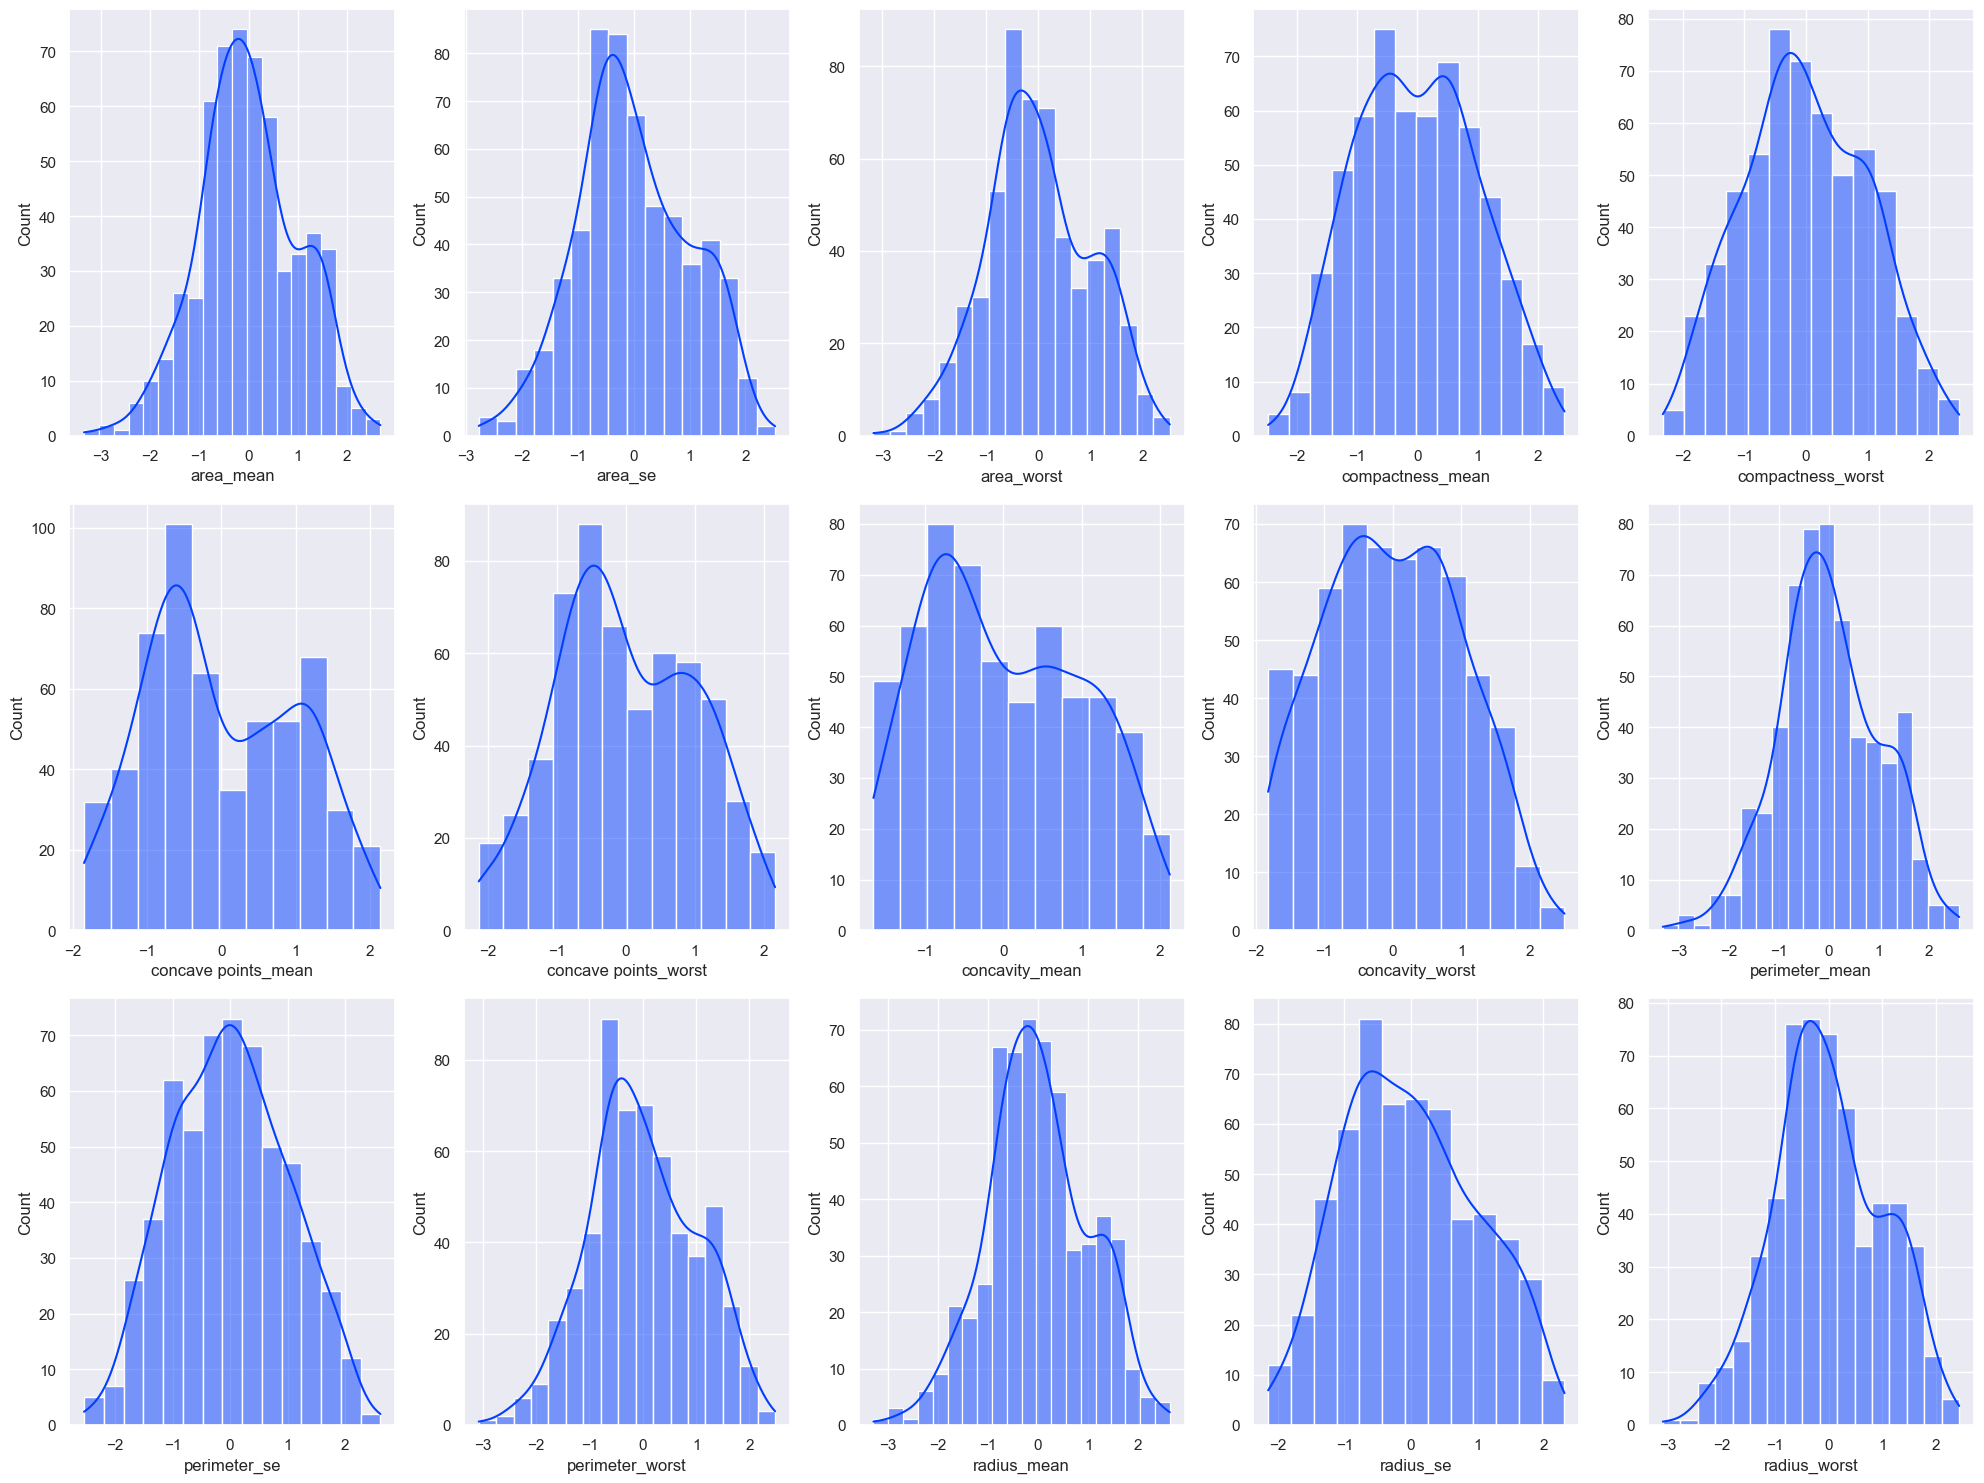

In [75]:
fig, axs = plt.subplots(3, 5, figsize=(20, 15))

for ax, coluna in zip(axs.flatten(), X_scaled.columns):
    sns.histplot(x=coluna, ax=ax, data=df_scaled, kde=True)

plt.tight_layout()
plt.show()

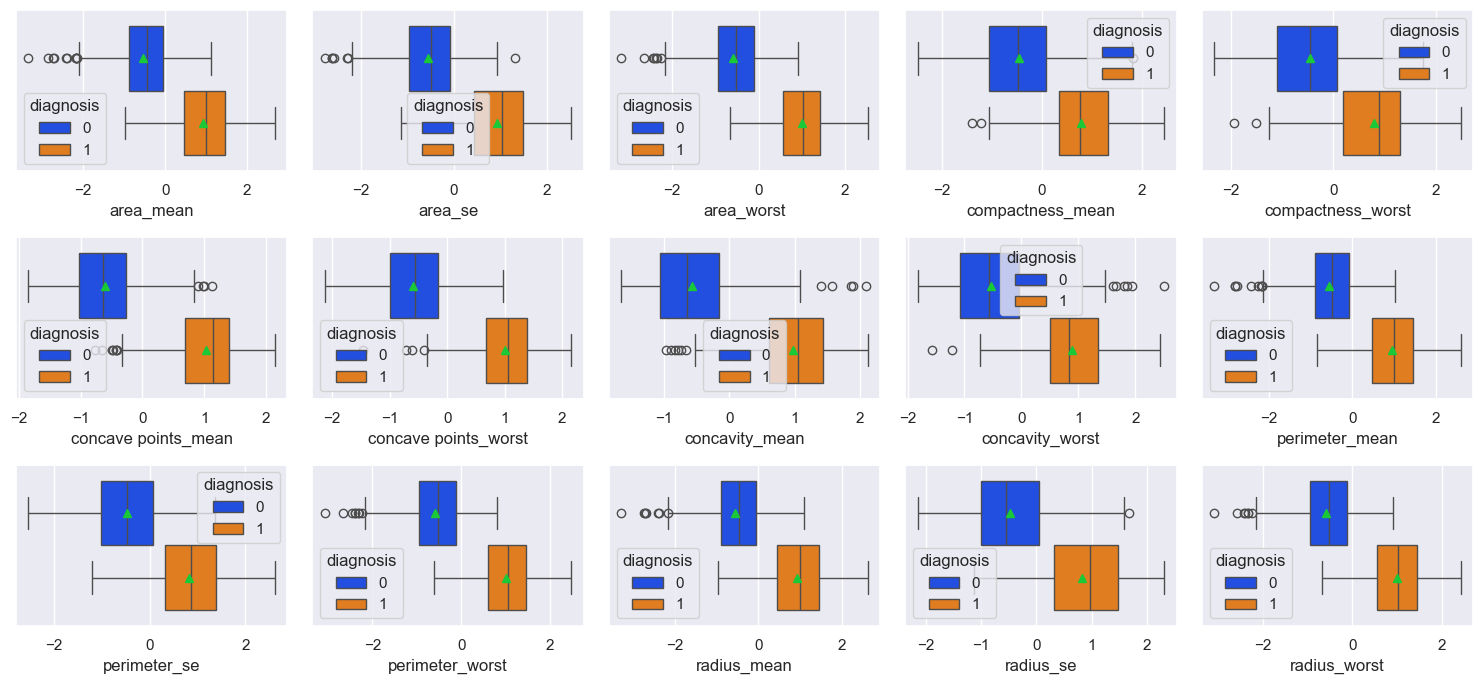

In [80]:
fig, axs = plt.subplots(3, 5, figsize=(15, 7))

for ax, coluna in zip(axs.flatten(), X_scaled.columns):
    sns.boxplot(x=coluna, ax=ax, data=df_scaled, showmeans=True, hue="diagnosis")

plt.tight_layout()
plt.show()